# Healthcare & Medical Analytics Project
## Chronic Kidney Disease (CKD) Prediction and EHR Analysis

### Objective
The goal of this project is to analyze Electronic Health Record (EHR) data and predict Chronic Kidney Disease (CKD) using machine learning and healthcare analytics techniques.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# APPLY DARK THEME
plt.style.use("dark_background")

# FIGURE SETTINGS
plt.rcParams["figure.figsize"] = (10,6)

# DARK COLORS
plt.rcParams["figure.facecolor"] = "#0F172A"
plt.rcParams["axes.facecolor"] = "#111827"

# GRID SETTINGS
plt.rcParams["grid.color"] = "gray"
plt.rcParams["grid.alpha"] = 0.3

# FONT SETTINGS
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13

# IMPORTANT
sns.set_theme(style=None)

# Load Dataset



In [ ]:
df = pd.read_csv("kidney_disease.csv")

In [ ]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,1
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,1
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,1
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,1


# Understanding the Dataset

We now examine:
- number of rows and columns
- column names
- data types
- missing values

In [ ]:
df.shape

(400, 26)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [ ]:
df.isnull().sum()

,0
id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


# Data Cleaning

The dataset contains:
- missing values
- question marks
- inconsistent formatting
- unnecessary columns

We clean the dataset before analysis.

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.drop("id", axis=1, inplace=True)

In [ ]:
df.replace("?", np.nan, inplace=True)

# Handling Missing Values

Healthcare datasets often contain incomplete patient records.

We use:
- Median Imputation for numerical values
- Mode Imputation for categorical values

In [ ]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

num_cols

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo'], dtype='object')

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [ ]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_3651/4074283006.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_3651/1925696021.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

# Target Column Conversion

The classification column contains:
- ckd
- notckd

We convert them into:
- 1 → CKD
- 0 → Non-CKD

In [ ]:
df['classification'] = df['classification'].replace({
    'ckd': 1,
    'notckd': 0
})

/tmp/ipykernel_3651/1437108426.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['classification'] = df['classification'].replace({


# Encoding Categorical Features

Machine learning models require numerical inputs.

We use Label Encoding to convert categorical features into numeric form.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    if col != 'classification':
        df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,30,69,30,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,24,53,30,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,17,67,30,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,18,59,17,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,21,65,24,0,0,0,0,0,0,1


In [ ]:
df.isnull().sum()

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0
bgr,0


# Save Cleaned Dataset

The cleaned dataset is saved for future analysis and machine learning implementation.

In [ ]:
df.to_csv("cleaned_kidney_disease.csv", index=False)

# Exploratory Data Analysis (EDA)

EDA helps identify:
- disease distribution
- biomarker relationships
- patient trends
- feature correlations

# CKD Distribution Analysis

This graph shows the number of CKD and non-CKD patients in the dataset.

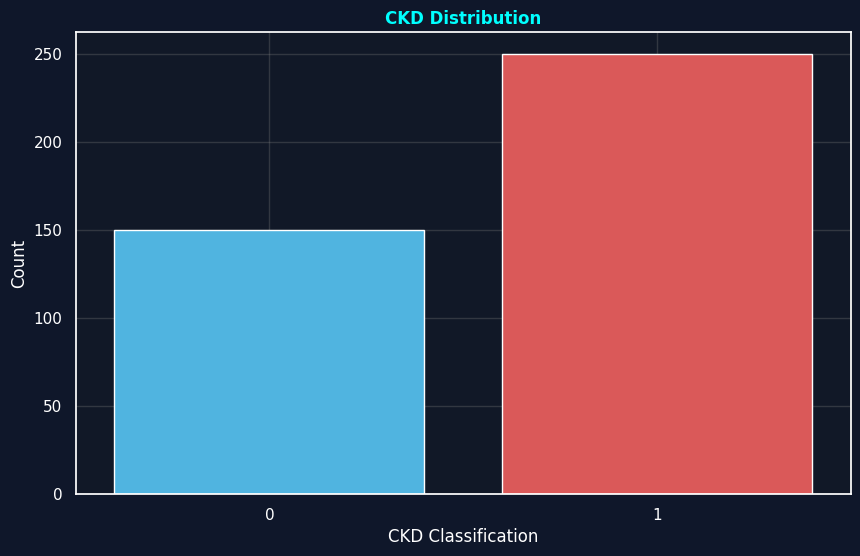

In [ ]:
sns.countplot(
    x='classification',
    hue='classification',
    data=df,
    palette=['#38BDF8','#EF4444'],
    legend=False
)

plt.title(
    "CKD Distribution",
    color='cyan',
    fontweight='bold'
)

plt.xlabel("CKD Classification")
plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

# Age Distribution Analysis

This visualization shows the distribution of patient ages in the dataset.

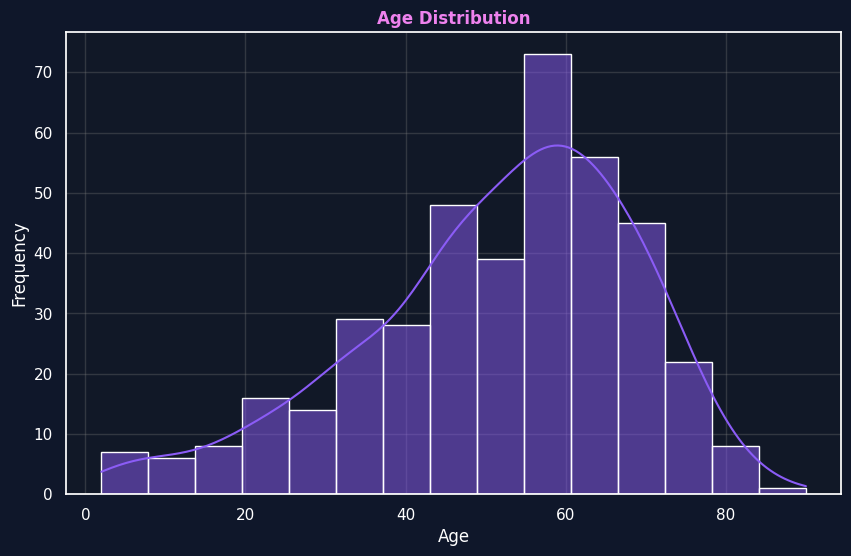

In [ ]:
sns.histplot(
    df['age'],
    kde=True,
    color='#8B5CF6'
)

plt.title(
    "Age Distribution",
    color='violet',
    fontweight='bold'
)

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

# Correlation Heatmap

The heatmap helps identify relationships between medical biomarkers and CKD.

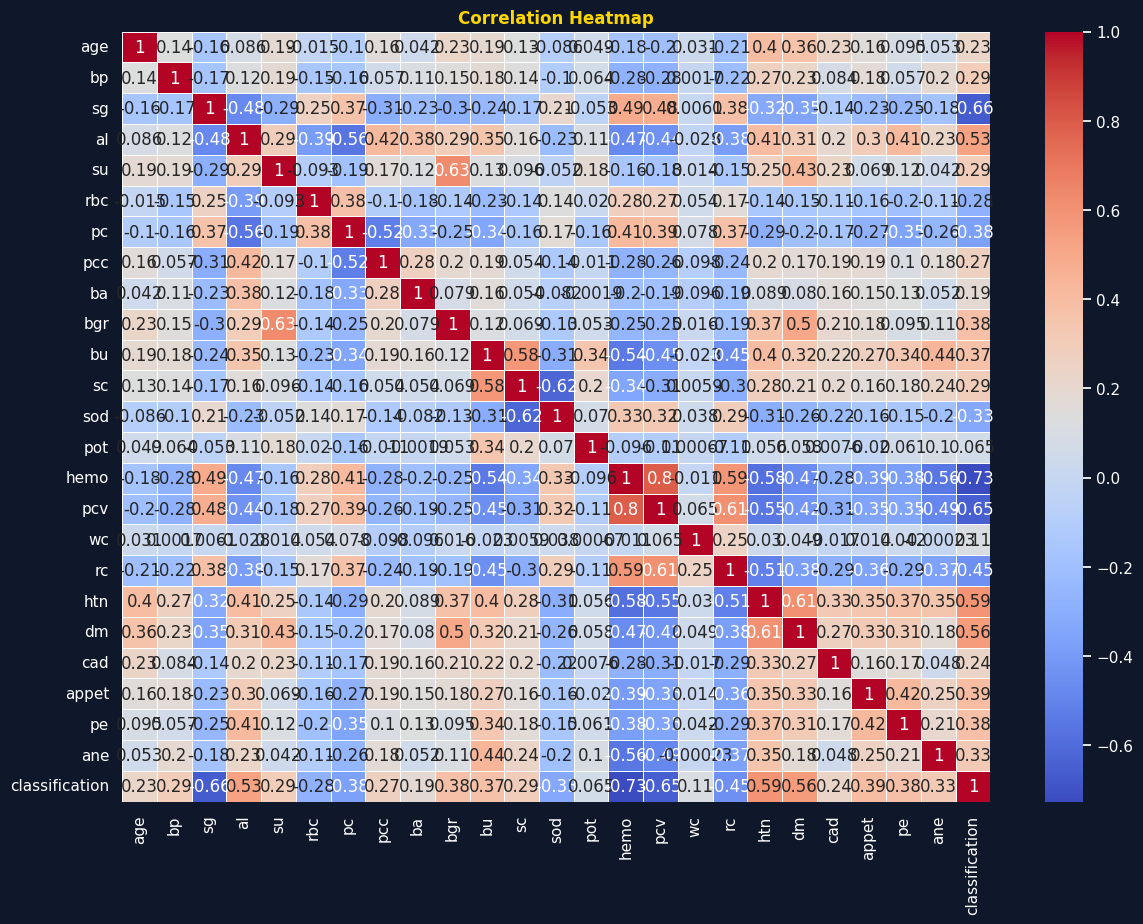

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=True,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    color='gold',
    fontweight='bold'
)

plt.show()

# Blood Pressure vs CKD

This analysis helps determine whether blood pressure is associated with CKD patients.

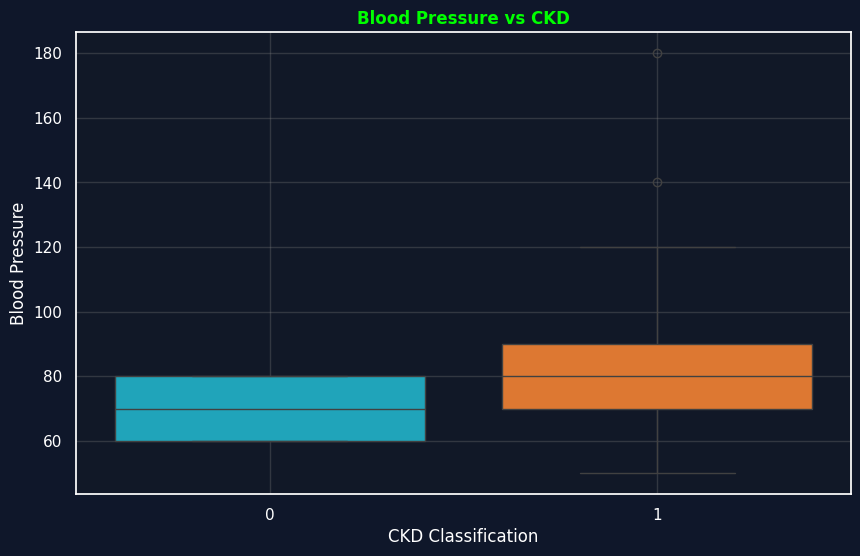

In [ ]:
sns.boxplot(
    x='classification',
    y='bp',
    hue='classification',
    data=df,
    palette=['#06B6D4','#F97316'],
    legend=False
)

plt.title(
    "Blood Pressure vs CKD",
    color='lime',
    fontweight='bold'
)

plt.xlabel("CKD Classification")
plt.ylabel("Blood Pressure")

plt.grid(alpha=0.3)

plt.show()

# Serum Creatinine Analysis

Serum Creatinine is an important biomarker for kidney disease detection.

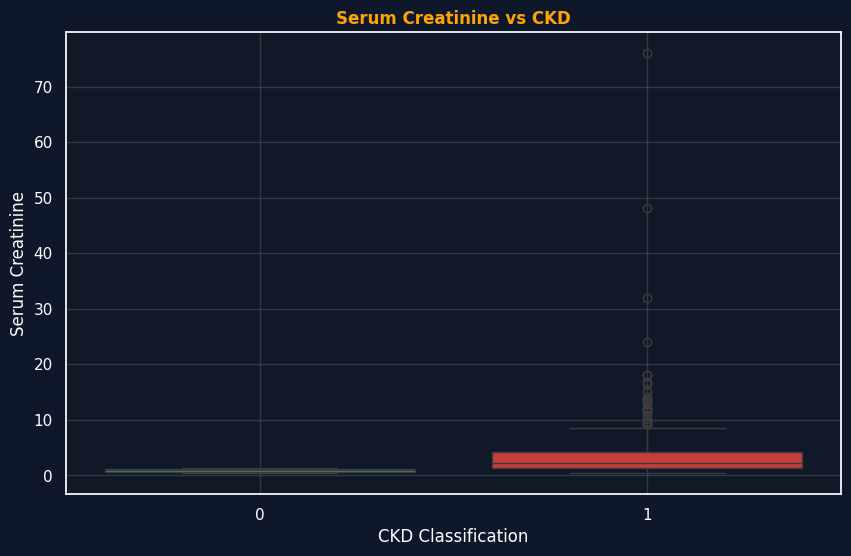

In [ ]:
sns.boxplot(
    x='classification',
    y='sc',
    hue='classification',
    data=df,
    palette=['#10B981','#DC2626'],
    legend=False
)

plt.title(
    "Serum Creatinine vs CKD",
    color='orange',
    fontweight='bold'
)

plt.xlabel("CKD Classification")
plt.ylabel("Serum Creatinine")

plt.grid(alpha=0.3)

plt.show()

# Scatter Plot Analysis

This scatter plot helps visualize the relationship between patient age and blood pressure for CKD and non-CKD patients.

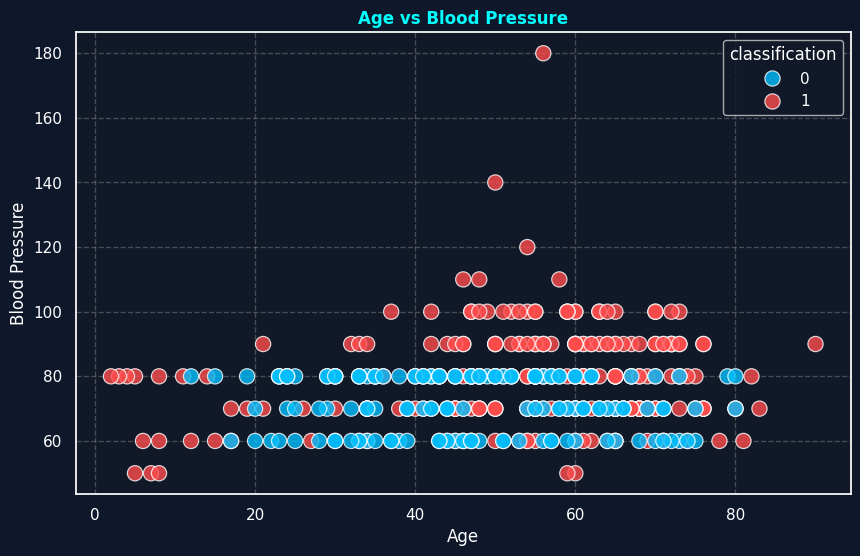

In [ ]:
sns.scatterplot(
    x='age',
    y='bp',
    hue='classification',
    data=df,
    palette=['#00BFFF','#FF4C4C'],
    s=120,
    alpha=0.8
)

plt.title(
    "Age vs Blood Pressure",
    color='cyan',
    fontweight='bold'
)

plt.xlabel("Age")
plt.ylabel("Blood Pressure")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Feature Correlation with CKD

This graph identifies the features most strongly associated with CKD.

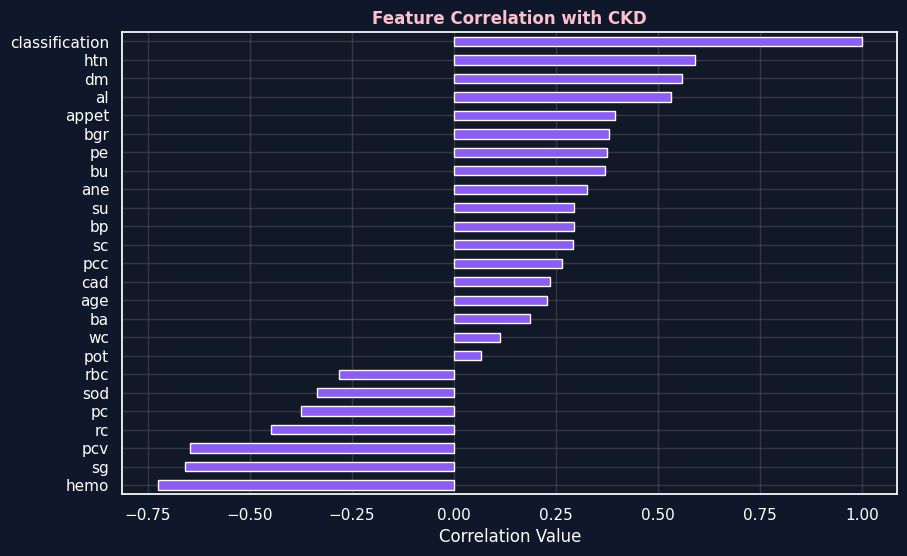

In [ ]:
corr = df.corr()['classification'].sort_values()

corr.plot(
    kind='barh',
    color='#8B5CF6'
)

plt.title(
    "Feature Correlation with CKD",
    color='pink',
    fontweight='bold'
)

plt.xlabel("Correlation Value")

plt.grid(alpha=0.3)

plt.show()

# Conclusion

In this phase of the project:
- the CKD dataset was cleaned,
- missing values were handled,
- categorical data was encoded,
- exploratory analysis was performed,
- and important biomarkers related to CKD were identified.

The dataset is now ready for machine learning implementation.

# Machine Learning Implementation

In this phase, machine learning algorithms are trained to predict Chronic Kidney Disease (CKD) using healthcare biomarker data.

In [ ]:
df = pd.read_csv("cleaned_kidney_disease.csv")

# Feature and Target Selection

The dataset is divided into:
- Features (X)
- Target Variable (y)

In [ ]:
# Convert everything to string
df['classification'] = df['classification'].astype(str)

# Remove spaces
df['classification'] = df['classification'].str.strip()

# Replace all possible values
df['classification'] = df['classification'].replace({
    'ckd': 1,
    'notckd': 0,
    'not ckd': 0,
    '1': 1,
    '0': 0
})

# Convert to integer
df['classification'] = df['classification'].astype(int)

# Check output
print(df['classification'].unique())

print(df['classification'].dtype)

[1 0]
int64


/tmp/ipykernel_1907/951597491.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['classification'] = df['classification'].replace({


In [ ]:
X = df[['age', 'bp', 'sg', 'al', 'su', 'sc', 'hemo']]

y = df['classification']

# Train-Test Split

The dataset is divided into:
- 80% Training Data
- 20% Testing Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression

Logistic Regression is used as a baseline classification model for CKD prediction.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
y_pred_log = log_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.95


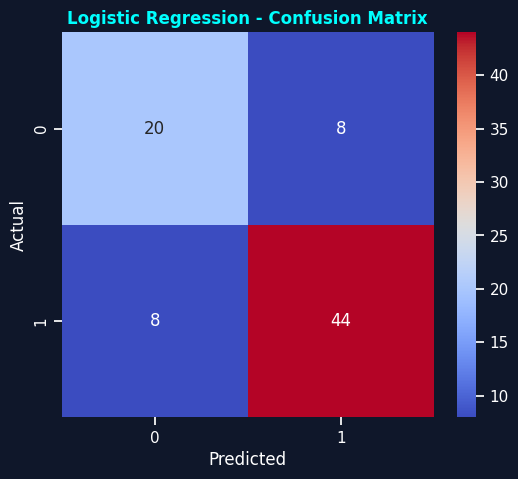

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title(
    "Logistic Regression - Confusion Matrix",
    color='cyan',
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        28
           1       0.98      0.94      0.96        52

    accuracy                           0.95        80
   macro avg       0.94      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



# Random Forest Classifier

Random Forest is used because it handles nonlinear healthcare data effectively and provides better accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## Test Model

In [ ]:
sample_low = [[25, 80, 1.020, 0, 0, 1.0, 15]]

sample_high = [[70, 170, 1.005, 5, 5, 10, 5]]

print("Low Risk:", rf.predict(sample_low))

print("High Risk:", rf.predict(sample_high))

Low Risk: [0]
High Risk: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, y_pred_log)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.975


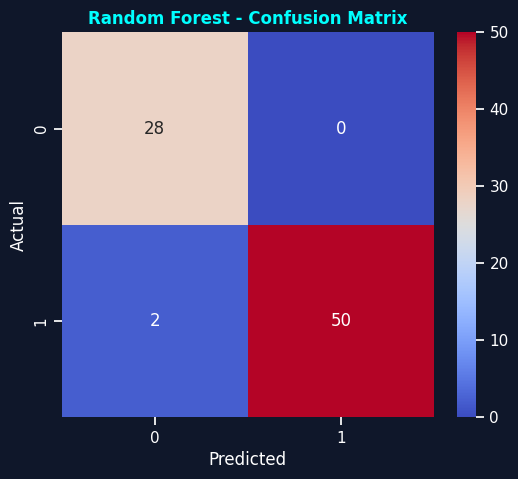

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title(
    "Random Forest - Confusion Matrix",
    color='cyan',
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        28
           1       1.00      0.96      0.98        52

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



# Model Accuracy Evaluation

Accuracy measures how correctly the machine learning model predicts CKD patients.

In [ ]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, y_pred_log)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy:", log_acc)

print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.8
Random Forest Accuracy: 0.975


# ROC-AUC Curve

ROC Curve evaluates the model’s ability to distinguish between CKD and non-CKD patients.

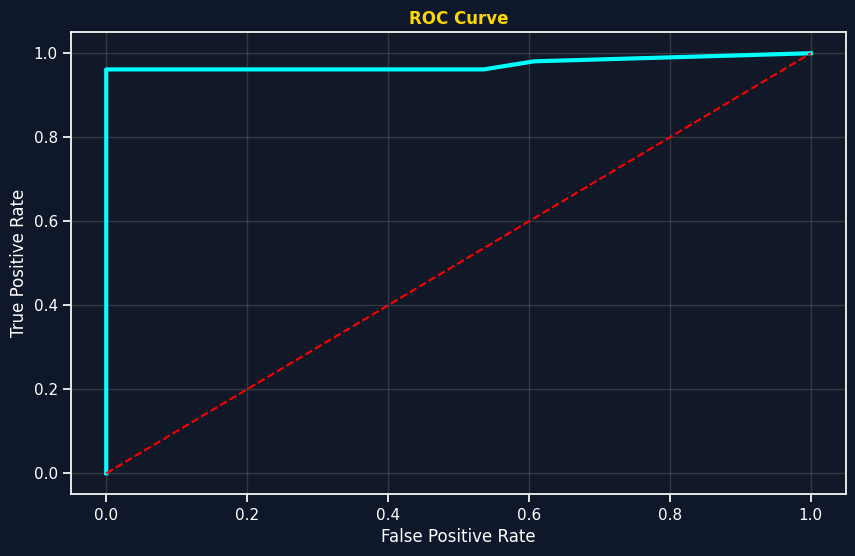

ROC-AUC Score: 0.9735576923076923


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(
    fpr,
    tpr,
    color='cyan',
    linewidth=3
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='red'
)

plt.title(
    "ROC Curve",
    color='gold',
    fontweight='bold'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.grid(alpha=0.3)

plt.show()

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, y_prob)
)

# Feature Importance Analysis

Feature importance identifies the healthcare biomarkers most influential for CKD prediction.

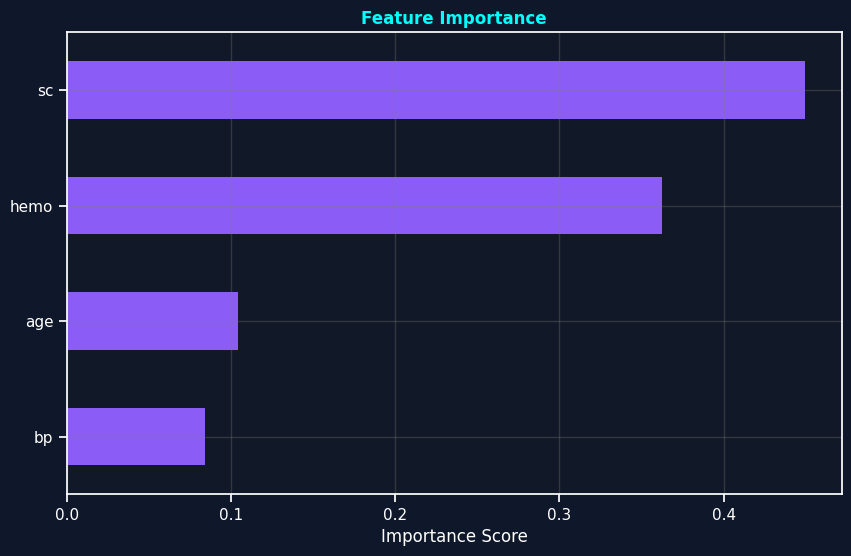

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    color='#8B5CF6'
)

plt.title(
    "Feature Importance",
    color='cyan',
    fontweight='bold'
)

plt.xlabel("Importance Score")

plt.grid(alpha=0.3)

plt.show()

# Save Machine Learning Model

The trained Random Forest model is saved for deployment and dashboard integration.

In [ ]:
import pickle

with open("ckd_model.pkl", "wb") as file:
    pickle.dump(rf, file)

print("Model saved successfully")

Model saved successfully
